# A/B Testing with Python — Udacity "Free Trial Screener" Experiment

This notebook walks through a complete A/B test analysis: choosing metrics, sizing the
experiment, running sanity checks on the collected data, measuring the effect size, and
double‑checking the conclusion with a non‑parametric sign test.

It's a cleaned‑up, self-contained rebuild of Tammy Rotem's popular Kaggle notebook
*"AB_Tests_with_Python"* (itself a walkthrough of the final project from Udacity's
*A/B Testing* course). The repeated boilerplate has been refactored into small reusable
functions, the analysis is illustrated with charts, and the notebook now loads its data
from local CSV files (`data/control_data.csv` and `data/experiment_data.csv`) shipped
alongside it, so it runs top-to-bottom with **no external dependencies or Kaggle paths**.

**Contents**
1. [Experiment background](#background)
2. [Choosing metrics](#metrics)
3. [Baseline values & variability](#baseline)
4. [Sizing the experiment](#sizing)
5. [Loading the collected data](#load)
6. [Sanity checks](#sanity)
7. [Effect size on the evaluation metrics](#effect)
8. [Sign test (a second, non-parametric check)](#sign)
9. [Conclusion](#conclusion)


In [1]:
import math as mt
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.8,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

CONTROL_COLOR = "#3b82f6"     # blue
EXPERIMENT_COLOR = "#f97316"  # orange
GOOD_COLOR = "#16a34a"        # green
BAD_COLOR = "#dc2626"         # red

pd.set_option("display.precision", 4)
%matplotlib inline

## 1. Experiment background <a id="background"></a>

**Product:** Udacity course pages currently show two buttons: *"start free trial"* and
*"access course materials"*. Anyone can browse the materials for free, but a 14‑day free
trial is required before a student can actually enroll and start earning a verified
certificate.

**The idea being tested:** when a visitor clicks *"start free trial"*, ask them up front
how many hours per week they can commit to the course. Students who say they don't have
much time are shown a message suggesting they browse the course materials for free
instead, without needing to start the trial. The goal is to set expectations early and
reduce the number of students who enroll, get discouraged by the time commitment, and
drop out before their 14 free days (and Udacity's revenue window) are up.

**Randomization unit:** a visitor is assigned to *control* or *experiment* the moment
they land on the course overview page, identified by browser cookie.

**Hypothesis:** this change will filter out some students who would never have finished
the course, *without* significantly reducing the number of students who go on to pay.
In other words, we expect **Gross Conversion** (clicks → enrollments) to drop, while
**Net Conversion** (clicks → paying users) stays about the same.


## 2. Choosing metrics <a id="metrics"></a>

Two families of metrics are needed:

- **Invariant metrics** — used purely as *sanity checks*. They should **not** be affected
  by the change, since they're measured before a visitor could even see it. If they move,
  something is wrong with the randomization or the data collection, and the experiment's
  results can't be trusted.
  - Number of cookies visiting the course overview page (**Pageviews**)
  - Number of clicks on the *"start free trial"* button (**Clicks**)
  - Click-through-probability on that button (**CTP** = Clicks / Pageviews)

- **Evaluation metrics** — the ones we actually expect to move, and that we'll use to
  judge whether the change is worth shipping.
  - **Gross Conversion** = Enrollments / Clicks — we expect this to *decrease*.
  - **Retention** = Payments / Enrollments — we expect this to *increase* (or stay flat).
  - **Net Conversion** = Payments / Clicks — we want this to *not* decrease meaningfully.

Practical significance thresholds ($d_{min}$, the smallest change worth caring about)
are set ahead of time: **1%** for Gross Conversion and Retention, **0.75%** for
Net Conversion.


## 3. Baseline values & variability <a id="baseline"></a>

Udacity supplied rough daily-traffic estimates from before the experiment. Rather than
size the experiment for the full ~40,000 daily cookies, we scale these estimates down to
a planning sample of **5,000 cookies/day**, which is the pageview volume the course
overview page realistically gets.


In [2]:
baseline = {
    "Cookies": 40000,       # daily unique cookies on course overview page
    "Clicks": 3200,         # daily unique cookies who click the trial button
    "Enrollments": 660,     # daily enrollments
    "CTP": 0.08,            # click-through-probability on the trial button
    "GConversion": 0.20625, # Gross Conversion
    "Retention": 0.53,      # Retention
    "NConversion": 0.109313 # Net Conversion
}

# Scale the daily counts down to our planning sample size of 5,000 pageviews/day
scale = 5000 / baseline["Cookies"]
baseline["Cookies"] = 5000
baseline["Clicks"] = round(baseline["Clicks"] * scale)
baseline["Enrollments"] = round(baseline["Enrollments"] * scale)

pd.Series(baseline, name="baseline (scaled to 5,000 pageviews/day)").to_frame()

,"baseline (scaled to 5,000 pageviews/day)"
Cookies,5000.0000
Clicks,400.0000
Enrollments,82.0000
CTP,0.0800
GConversion,0.2062
Retention,0.5300
NConversion,0.1093


Because probabilities like Gross Conversion and Net Conversion are proportions of a
binomial process, their standard deviation can be estimated analytically with

$$SD = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

as long as the **unit of diversion** (cookie) matches the **unit of analysis** (the
denominator of the metric). That's true for Gross Conversion and Net Conversion (both
divide by *clicks*, which is also how visitors are diverted into control/experiment) —
but **not** for Retention, whose denominator is *enrollments*, a subset of clicks. We
keep the analytical estimate for Retention as a rough approximation, flagging that it's
less trustworthy.


In [3]:
def analytic_sd(p, n):
    """Analytic standard deviation of a sample proportion p from n trials."""
    return round(mt.sqrt((p * (1 - p)) / n), 4)

GC = {"d_min": 0.01,   "p": baseline["GConversion"], "n": baseline["Clicks"]}
R  = {"d_min": 0.01,   "p": baseline["Retention"],   "n": baseline["Enrollments"]}
NC = {"d_min": 0.0075, "p": baseline["NConversion"], "n": baseline["Clicks"]}

for metric in (GC, R, NC):
    metric["sd"] = analytic_sd(metric["p"], metric["n"])

pd.DataFrame({"Gross Conversion": GC, "Retention": R, "Net Conversion": NC}).T

,d_min,p,n,sd
Gross Conversion,0.0100,0.2062,400.0,0.0202
Retention,0.0100,0.5300,82.0,0.0551
Net Conversion,0.0075,0.1093,400.0,0.0156


## 4. Sizing the experiment <a id="sizing"></a>

Given a significance level $\alpha=0.05$ and power $1-\beta=0.8$, how many total
pageviews do we need per metric? We use the standard two-proportion sample-size formula:

$$n = \frac{(Z_{1-\alpha/2}\,sd_1 + Z_{1-\beta}\,sd_2)^2}{d^2}$$


In [4]:
def get_z_score(alpha):
    """z-score for a given cumulative probability."""
    return norm.ppf(alpha)

def get_sds(p, d):
    """Standard deviations of the two proportions being compared (p and p+d)."""
    sd1 = mt.sqrt(2 * p * (1 - p))
    sd2 = mt.sqrt(p * (1 - p) + (p + d) * (1 - (p + d)))
    return sd1, sd2

def get_sample_size(sds, alpha, beta, d):
    sd1, sd2 = sds
    z_alpha = get_z_score(1 - alpha / 2)
    z_beta = get_z_score(1 - beta)
    return ((z_alpha * sd1 + z_beta * sd2) / d) ** 2

def clicks_needed(metric):
    return round(get_sample_size(get_sds(metric["p"], metric["d_min"]), 0.05, 0.2, metric["d_min"]))

def pageviews_needed(metric, clicks_per_group, ctp=baseline["Clicks"] / baseline["Cookies"], clicks_to_enrollments_rate=1.0):
    """Convert a per-group 'clicks' requirement into total pageviews (both groups)."""
    return round(clicks_per_group / ctp * 2 / clicks_to_enrollments_rate)

GC["clicks_needed"] = clicks_needed(GC)
GC["pageviews_needed"] = pageviews_needed(GC, GC["clicks_needed"])

R["enrollments_needed"] = clicks_needed(R)
# Enrollments -> clicks -> pageviews
R["pageviews_needed"] = pageviews_needed(
    R, R["enrollments_needed"], clicks_to_enrollments_rate=baseline["GConversion"]
)

NC["clicks_needed"] = clicks_needed(NC)
NC["pageviews_needed"] = pageviews_needed(NC, NC["clicks_needed"])

sizing = pd.DataFrame({"Gross Conversion": GC, "Retention": R, "Net Conversion": NC}).T
sizing[["clicks_needed", "pageviews_needed"]]

,clicks_needed,pageviews_needed
Gross Conversion,25835.0,645875.0
Retention,NaN,4737818.0
Net Conversion,27413.0,685325.0


Retention alone would need well over **4 million pageviews** — with ~40,000 daily
pageviews, that's over 100 days of traffic, which is impractical. **Retention is dropped**
from the analysis. Gross Conversion and Net Conversion are more reasonable, and since we
run every metric on the *same* collected data, the experiment must be sized for
whichever metric needs the most pageviews.


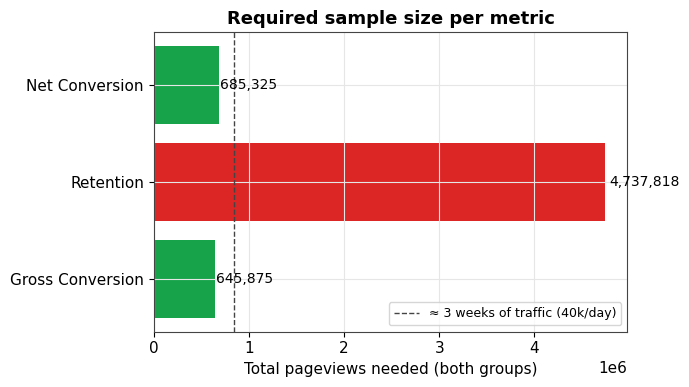

Retention would need 4,737,818 pageviews — 118 days of traffic. Dropping it.
The experiment will be sized for Net Conversion: 685,325 pageviews (≈ 17 days at 40k pageviews/day).


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
names = ["Gross Conversion", "Retention", "Net Conversion"]
values = [GC["pageviews_needed"], R["pageviews_needed"], NC["pageviews_needed"]]
colors = [GOOD_COLOR, BAD_COLOR, GOOD_COLOR]

bars = ax.barh(names, values, color=colors)
ax.set_xlabel("Total pageviews needed (both groups)")
ax.set_title("Required sample size per metric")
ax.axvline(40000 * 21, color="#444444", ls="--", lw=1, label="≈ 3 weeks of traffic (40k/day)")
for bar, v in zip(bars, values):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{v:,.0f}",
            va="center", fontsize=10)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Retention would need {R['pageviews_needed']:,.0f} pageviews — "
      f"{R['pageviews_needed'] / 40000:.0f} days of traffic. Dropping it.")
print(f"The experiment will be sized for Net Conversion: {NC['pageviews_needed']:,.0f} "
      f"pageviews (≈ {NC['pageviews_needed'] / 40000:.0f} days at 40k pageviews/day).")

## 5. Loading the collected data <a id="load"></a>

The experiment ran for 37 days. Each row is one day's totals for the control and
experiment groups.


In [6]:
control = pd.read_csv("data/control_data.csv")
experiment = pd.read_csv("data/experiment_data.csv")
control.head()

,Date,Pageviews,Clicks,Enrollments,Payments
0,"Sat, Oct 11",7723,687,134.0,70.0
1,"Sun, Oct 12",9102,779,147.0,70.0
2,"Mon, Oct 13",10511,909,167.0,95.0
3,"Tue, Oct 14",9871,836,156.0,105.0
4,"Wed, Oct 15",10014,837,163.0,64.0


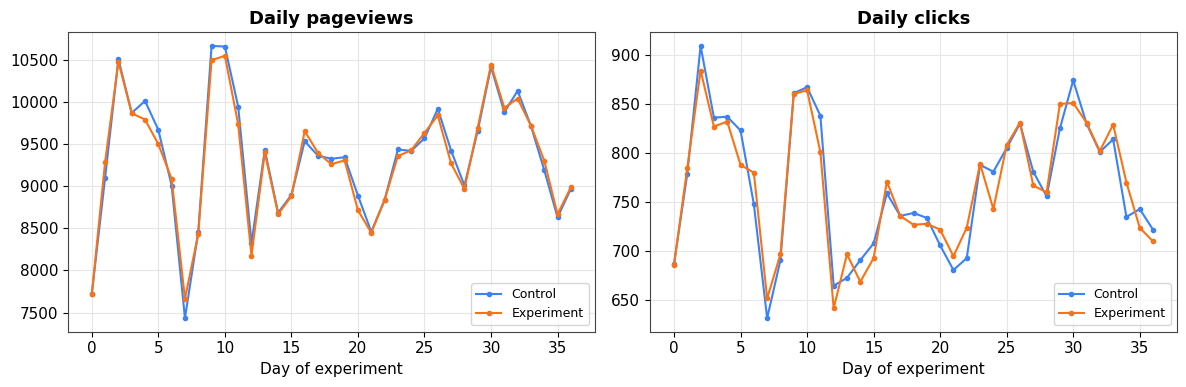

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Pageviews", "Clicks"]):
    ax.plot(control.index, control[col], label="Control", color=CONTROL_COLOR, marker="o", ms=3)
    ax.plot(experiment.index, experiment[col], label="Experiment", color=EXPERIMENT_COLOR, marker="o", ms=3)
    ax.set_title(f"Daily {col.lower()}")
    ax.set_xlabel("Day of experiment")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Sanity checks <a id="sanity"></a>

Before trusting the evaluation metrics, we check that the invariant metrics behaved as
expected — i.e. that nothing about *how* visitors were split or counted was broken.

### Counts (Pageviews, Clicks)
Control and experiment should each get about **half** of the total. We model the
proportion landing in control as a Binomial($n$, $p=0.5$), approximate it with a normal
distribution, and check that the *observed* control share falls inside a 95% confidence
interval around 0.5.

### Proportions (CTP)
For a metric that's already a proportion (Click-Through-Probability), we instead check
that the *difference* between the two groups' CTP is close enough to zero, using a
pooled standard error.

Both checks are refactored into two small reusable functions below.


In [8]:
def sanity_check_count(cont_total, exp_total, alpha=0.05):
    """Sanity check for a raw count that should split ~50/50 between groups."""
    total = cont_total + exp_total
    p_hat = cont_total / total
    sd = mt.sqrt(0.5 * 0.5 / total)
    me = get_z_score(1 - alpha / 2) * sd
    lower, upper = 0.5 - me, 0.5 + me
    passed = lower <= p_hat <= upper
    return {"control_share": round(p_hat, 4), "ci_low": round(lower, 4),
            "ci_high": round(upper, 4), "passed": passed}

def sanity_check_probability(cont_num, cont_den, exp_num, exp_den, alpha=0.05):
    """Sanity check that two groups' proportions (e.g. CTP) are statistically equal."""
    p_cont, p_exp = cont_num / cont_den, exp_num / exp_den
    d_hat = p_exp - p_cont
    p_pooled = (cont_num + exp_num) / (cont_den + exp_den)
    sd_pooled = mt.sqrt(p_pooled * (1 - p_pooled) * (1 / cont_den + 1 / exp_den))
    me = get_z_score(1 - alpha / 2) * sd_pooled
    passed = -me <= d_hat <= me
    return {"observed_diff": round(d_hat, 4), "ci_low": round(-me, 4),
            "ci_high": round(me, 4), "passed": passed}

pageviews_cont, pageviews_exp = control["Pageviews"].sum(), experiment["Pageviews"].sum()
clicks_cont, clicks_exp = control["Clicks"].sum(), experiment["Clicks"].sum()

sanity_results = {
    "Pageviews (count)": sanity_check_count(pageviews_cont, pageviews_exp),
    "Clicks (count)": sanity_check_count(clicks_cont, clicks_exp),
    "CTP (proportion)": sanity_check_probability(clicks_cont, pageviews_cont, clicks_exp, pageviews_exp),
}

sanity_df = pd.DataFrame(sanity_results).T
sanity_df["passed"] = sanity_df["passed"].map({True: "✅ pass", False: "❌ fail"})
sanity_df

,control_share,ci_low,ci_high,passed,observed_diff
Pageviews (count),0.5006,0.4988,0.5012,✅ pass,NaN
Clicks (count),0.5005,0.4959,0.5041,✅ pass,NaN
CTP (proportion),NaN,-0.0013,0.0013,✅ pass,0.0001


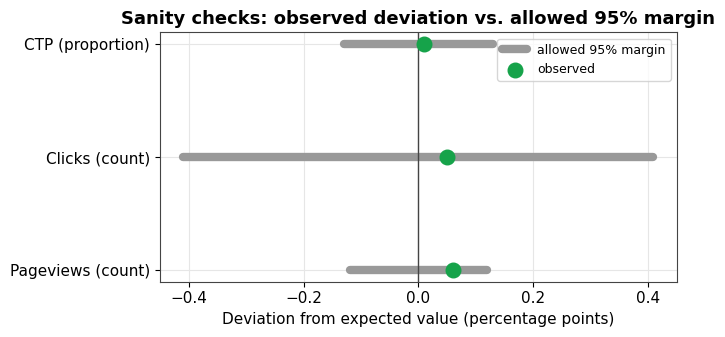

In [9]:
# Express everything as a deviation from the expected center, in percentage points,
# so checks with a tiny allowed margin (counts) and a wider one (CTP) are comparable
# on one chart.
fig, ax = plt.subplots(figsize=(7, 3.5))
checks = list(sanity_results.keys())
for i, name in enumerate(checks):
    r = sanity_results[name]
    if "control_share" in r:
        center, obs = 0.5, r["control_share"]
    else:
        center, obs = 0.0, r["observed_diff"]
    half_width = (r["ci_high"] - r["ci_low"]) / 2 * 100
    deviation = (obs - center) * 100
    color = GOOD_COLOR if r["passed"] else BAD_COLOR

    ax.plot([-half_width, half_width], [i, i], color="#999999", lw=6, solid_capstyle="round",
            label="allowed 95% margin" if i == 0 else None)
    ax.scatter([deviation], [i], color=color, s=110, zorder=3,
               label="observed" if i == 0 else None)

ax.axvline(0, color="#444444", lw=1)
ax.set_yticks(range(len(checks)))
ax.set_yticklabels(checks)
ax.set_xlabel("Deviation from expected value (percentage points)")
ax.set_title("Sanity checks: observed deviation vs. allowed 95% margin")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

All three invariant metrics fall inside their expected range — the sanity checks
**pass**, so we can move on and trust the evaluation metrics.


## 7. Effect size on the evaluation metrics <a id="effect"></a>

Now the interesting part: did Gross Conversion and Net Conversion actually change, and
was that change big enough to matter? A metric only "counts" as significant if:

1. its confidence interval does **not** contain 0 (statistically significant), **and**
2. its absolute value clears the $d_{min}$ threshold set back in Section 3
   (practically significant).

Only rows with non-null `Enrollments`/`Payments` are used, since a handful of trailing
days hadn't finished their 14-day enrollment window yet when the data was pulled.


In [10]:
def evaluate_metric(name, cont_num, cont_den, exp_num, exp_den, d_min, alpha=0.05):
    p_cont, p_exp = cont_num / cont_den, exp_num / exp_den
    diff = p_exp - p_cont
    p_pooled = (cont_num + exp_num) / (cont_den + exp_den)
    sd_pooled = mt.sqrt(p_pooled * (1 - p_pooled) * (1 / cont_den + 1 / exp_den))
    me = get_z_score(1 - alpha / 2) * sd_pooled
    ci_low, ci_high = diff - me, diff + me
    stat_sig = not (ci_low <= 0 <= ci_high)
    prac_sig = abs(diff) > d_min
    return {
        "metric": name, "control_rate": p_cont, "experiment_rate": p_exp,
        "diff": diff, "ci_low": ci_low, "ci_high": ci_high, "d_min": d_min,
        "statistically_significant": stat_sig, "practically_significant": prac_sig,
    }

complete = control["Enrollments"].notnull()
clicks_cont_c = control["Clicks"].loc[complete].sum()
clicks_exp_c = experiment["Clicks"].loc[complete].sum()

gc_result = evaluate_metric(
    "Gross Conversion",
    control["Enrollments"].sum(), clicks_cont_c,
    experiment["Enrollments"].sum(), clicks_exp_c,
    GC["d_min"],
)
nc_result = evaluate_metric(
    "Net Conversion",
    control["Payments"].sum(), clicks_cont_c,
    experiment["Payments"].sum(), clicks_exp_c,
    NC["d_min"],
)

effect_df = pd.DataFrame([gc_result, nc_result]).set_index("metric")
effect_df

,control_rate,experiment_rate,diff,ci_low,ci_high,d_min,statistically_significant,practically_significant
metric,,,,,,,,
Gross Conversion,0.2189,0.1983,-0.0206,-0.0291,-0.0120,0.0100,True,True
Net Conversion,0.1176,0.1127,-0.0049,-0.0116,0.0019,0.0075,False,False


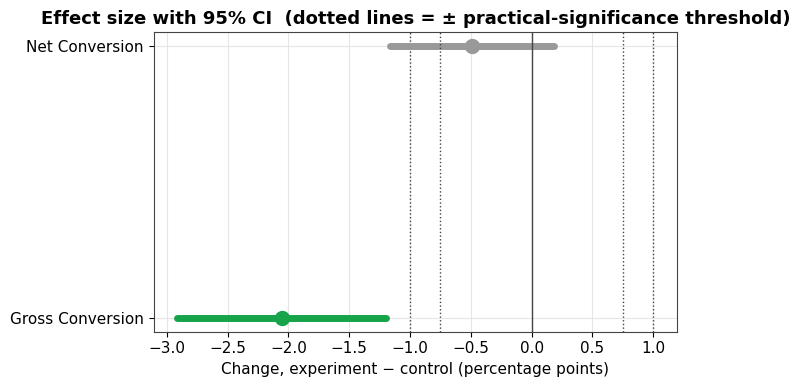

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
for i, row in enumerate(effect_df.itertuples()):
    color = GOOD_COLOR if (row.statistically_significant and row.practically_significant) else \
            (BAD_COLOR if row.statistically_significant else "#999999")
    ax.plot([row.ci_low * 100, row.ci_high * 100], [i, i], color=color, lw=5, solid_capstyle="round")
    ax.scatter([row.diff * 100], [i], color=color, s=100, zorder=3)
    ax.axvline(row.d_min * 100, color="#444444", ls=":", lw=1)
    ax.axvline(-row.d_min * 100, color="#444444", ls=":", lw=1)

ax.axvline(0, color="#444444", lw=1)
ax.set_yticks(range(len(effect_df)))
ax.set_yticklabels(effect_df.index)
ax.set_xlabel("Change, experiment − control (percentage points)")
ax.set_title("Effect size with 95% CI  (dotted lines = ± practical-significance threshold)")
plt.tight_layout()
plt.show()

**Gross Conversion** dropped, its confidence interval excludes 0, and the drop is
larger than the 1-point practical-significance threshold — so it's both statistically
**and** practically significant. Fewer people enrolled in the free trial after being
asked up front how much time they could commit — exactly as hypothesized.

**Net Conversion**'s confidence interval straddles 0 well within the ±0.75-point
threshold, so the drop we see is not statistically significant. The change did **not**
meaningfully hurt the number of students who go on to pay.


## 8. Sign test (a second, non-parametric check) <a id="sign"></a>

As a robustness check that doesn't rely on the normal approximation above, we look at
each day individually: on how many of the 23 days with complete data did the experiment
group's metric beat the control group's? Under the null hypothesis of "no real
difference," that count should behave like a fair coin flip (Binomial($n$, 0.5)).


In [12]:
full = control.join(experiment, how="inner", lsuffix="_cont", rsuffix="_exp")
full = full.loc[full["Enrollments_cont"].notnull()]

full["GC_cont"] = full["Enrollments_cont"] / full["Clicks_cont"]
full["GC_exp"] = full["Enrollments_exp"] / full["Clicks_exp"]
full["NC_cont"] = full["Payments_cont"] / full["Clicks_cont"]
full["NC_exp"] = full["Payments_exp"] / full["Clicks_exp"]

full["GC_exp_wins"] = (full["GC_exp"] < full["GC_cont"]).astype(int)  # lower GC = expected direction
full["NC_exp_wins"] = (full["NC_exp"] >= full["NC_cont"]).astype(int)  # flat/higher NC = expected direction

n_days = len(full)
gc_wins = full["GC_exp_wins"].sum()
nc_wins = full["NC_exp_wins"].sum()
print(f"Days in expected direction — Gross Conversion: {gc_wins}/{n_days},  "
      f"Net Conversion: {nc_wins}/{n_days}")

Days in expected direction — Gross Conversion: 19/23,  Net Conversion: 10/23


In [13]:
def binomial_prob(x, n, p=0.5):
    return mt.comb(n, x) * (p ** x) * ((1 - p) ** (n - x))

def two_sided_sign_test_pvalue(x, n):
    """Two-sided p-value for the number of 'successes' x out of n fair coin flips."""
    extreme = min(x, n - x)
    return 2 * sum(binomial_prob(i, n) for i in range(extreme + 1))

gc_p = two_sided_sign_test_pvalue(int(n_days - gc_wins), n_days)  # count days GC *increased* (unexpected) vs not
nc_p = two_sided_sign_test_pvalue(int(nc_wins), n_days)

print(f"Gross Conversion sign-test p-value: {gc_p:.4f}  -> "
      f"{'significant' if gc_p < 0.05 else 'not significant'} at alpha=0.05")
print(f"Net Conversion sign-test p-value:   {nc_p:.4f}  -> "
      f"{'significant' if nc_p < 0.05 else 'not significant'} at alpha=0.05")

Gross Conversion sign-test p-value: 0.0026  -> significant at alpha=0.05
Net Conversion sign-test p-value:   0.6776  -> not significant at alpha=0.05


The sign test agrees with the confidence-interval analysis above: the shift in
Gross Conversion shows up consistently, day after day, while Net Conversion looks like
noise around a coin flip.


## 9. Conclusion & recommendation <a id="conclusion"></a>

The screener did what it was designed to do: fewer visitors enrolled in the free trial
(Gross Conversion fell, clearly and consistently), which is the intended filtering
effect. Crucially, it did **not** come at a meaningful cost to the number of students who
went on to pay (Net Conversion was flat, within noise).

On the numbers alone this looks like a reasonable trade: fewer discouraged students
starting (and later abandoning) the trial, without losing paying customers. Whether to
ship the change more broadly would also depend on qualitative factors this data can't
capture — student sentiment, support-ticket volume, and effects on longer-run measures
like course completion or word-of-mouth — that weren't part of this particular
experiment's metric set.

---
*Adapted from Tammy Rotem's ["AB_Tests_with_Python"](https://www.kaggle.com/code/tammyrotem/ab-tests-with-python)
Kaggle notebook, itself a walkthrough of the final project for Udacity's
[A/B Testing course](https://www.udacity.com/course/ab-testing--ud257). Data:
[`control_data.csv`](https://www.kaggle.com/datasets/tammyrotem/control-data) /
[`experiment_data.csv`](https://www.kaggle.com/datasets/tammyrotem/experiment-data),
bundled locally in `data/` for a fully offline, runnable notebook.*
